# RL-6 : Introduction a l'Apprentissage Multi-Agent

**Serie** : Reinforcement Learning | **Notebook** : 6/6 | **Duree estimee** : 45-50 min

Navigation : [RL-1 Intro](stable_baseline_1_intro_cartpole.ipynb) | [RL-2 Wrappers](stable_baseline_2_wrappers_sauvegarde_callbacks.ipynb) | [RL-3 HER](stable_baseline_3_experience_replay_dqn.ipynb) | [RL-4 Tabulaire](rl_4_mdp_dp_qlearning.ipynb) | [RL-5 DQN/PG](rl_5_dqn_policy_gradient.ipynb) | **RL-6**

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :
- Comprendre les defis specifiques de l'apprentissage multi-agent (non-stationnarite, credit assignment)
- Utiliser la librairie PettingZoo pour les environnements multi-agent
- Implementer un Independent Q-Learning (IQL) pour plusieurs agents
- Observer les phenomenes d'emergence dans les systemes multi-agent

## Prerequis

- [RL-4 Q-Learning tabulaire](rl_4_mdp_dp_qlearning.ipynb) (Q-Learning, epsilon-greedy)
- Notions de theorie des jeux (equilibre de Nash, dilemme du prisonnier)
- Bases numpy et matplotlib

---

**Pourquoi le multi-agent ?**
- La plupart des problemes reels impliquent plusieurs entites qui interagissent : robots collaboratifs, marches financiers, jeux a plusieurs joueurs, reseaux de communication.
- Chaque agent doit apprendre une politique adaptee au comportement des autres agents, qui apprennent simultanement.
- L'environnement devient **non-stationnaire** du point de vue d'un seul agent, ce qui complique l'apprentissage.

## 1. Installation et imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import tictactoe_v3

print("PettingZoo charge avec succes")

PettingZoo charge avec succes


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import tictactoe_v3

print("PettingZoo charge avec succes")

PettingZoo charge avec succes


[PettingZoo](https://pettingzoo.farama.org/) est la librairie de reference pour les environnements multi-agent en Python. Elle suit l'API AEC (Agent Environment Cycle) ou les agents jouent sequentiellement.

Nous utiliserons **TicTacToe-v3** : un jeu a somme nulle a deux joueurs, parfait pour illustrer les concepts multi-agent dans un espace d'etat discret (3^9 etats possibles).

## 2. Comprendre l'API PettingZoo

Contrairement a Gymnasium (un seul agent), PettingZoo gere plusieurs agents qui agissent tour a tour. L'API AEC (Agent Environment Cycle) fonctionne ainsi :

1. `env.reset()` : Reinitialise l'environnement
2. `env.agent_selection` : Indique quel agent doit jouer
3. `env.observe(agent)` : Retourne l'observation pour cet agent
4. `env.step(action)` : L'agent joue son coup
5. `env.terminations` / `env.truncations` : Verifie la fin de partie

In [3]:
# Explorer l'environnement TicTacToe
env = tictactoe_v3.env()
env.reset(seed=42)

print(f"Agents possibles : {env.possible_agents}")
print(f"Agent actuel      : {env.agent_selection}")

obs = env.observe(env.agent_selection)
print(f"\nForme de l'observation : {obs['observation'].shape}")
print(f"Masque d'action        : {obs['action_mask']}")
print(f"\nEspaces d'action : {env.action_space(env.possible_agents[0])}")
print(f"Espaces d'obs     : {env.observation_space(env.possible_agents[0])}")

Agents possibles : ['player_1', 'player_2']
Agent actuel      : player_1

Forme de l'observation : (3, 3, 2)
Masque d'action        : [1 1 1 1 1 1 1 1 1]

Espaces d'action : Discrete(9)
Espaces d'obs     : Dict('action_mask': Box(0, 1, (9,), int8), 'observation': Box(0, 1, (3, 3, 2), int8))


L'observation est un tenseur de forme (3, 3, 2) : 1 canal pour les marques du joueur 1, 1 canal pour les marques du joueur 2. Le masque d'action indique les cases valides (1 = jouable, 0 = deja prise).

In [4]:
# Jouer une partie aleatoire pour comprendre le deroulement
env = tictactoe_v3.env()
env.reset(seed=42)

board = ['.' for _ in range(9)]
marks = {'player_1': 'X', 'player_2': 'O'}

for agent in env.agent_iter():
    obs, reward, termination, truncation, info = env.last()
    if termination or truncation:
        break
    
    # Choisir une action aleatoire parmi les actions valides
    action_mask = obs['action_mask']
    valid_actions = np.where(action_mask == 1)[0]
    action = np.random.choice(valid_actions)
    
    board[action] = marks[agent]
    env.step(action)

# Afficher la grille finale
print("Grille finale :")
for i in range(3):
    print(' '.join(board[i*3:(i+1)*3]))

# Resultats
print(f"\nRecompenses finales : {env.rewards}")
print(f"Terminaisons        : {env.terminations}")

Grille finale :
O X X
O O X
X O X

Recompenses finales : {'player_1': 1, 'player_2': -1}
Terminaisons        : {'player_1': True, 'player_2': True}


Dans TicTacToe, les recompenses sont :
- **+1** pour le gagnant
- **-1** pour le perdant
- **0** pour chaque joueur en cas de match nul

Le jeu est a somme nulle : la somme des recompenses est toujours nulle.

## 3. Concepts du Multi-Agent RL

### Paradigmes d'apprentissage

| Paradigme | Description | Exemple |
|-----------|-------------|----------|
| **Cooperatif** | Les agents maximisent une recompense commune | Robots collaboratifs |
| **Competitif** | Les agents maximisent leur propre recompense (somme nulle) | Echecs, Go |
| **Mixte** | Cooperation et competition partielles | Marches financiers |

### Defis principaux

1. **Non-stationnarite** : L'environnement change pour chaque agent car les autres agents apprennent
2. **Credit assignment** : Difficile d'attribuer le succes/echec a un agent en particulier
3. **Equilibre** : Les agents peuvent converger vers des politiques sous-optimales (cycles)
4. **Scalabilite** : L'espace conjoint croit exponentiellement avec le nombre d'agents

## 4. Independent Q-Learning (IQL)

L'approche la plus simple : chaque agent apprend independamment avec son propre Q-Learning, en traitant les autres agents comme faisant partie de l'environnement.

**Avantage** : Simple a implementer, scalable.

**Inconvenient** : Non-stationnarite (les "autres agents" changent de comportement au fil de l'entrainement).

Pour TicTacToe, chaque agent dispose de sa propre table Q qui mappe (etat, action) -> Q-valeur. L'etat est encode comme un entier unique representant la configuration du plateau.

In [5]:
def encode_observation(obs):
    """
    Encode l'observation PettingZoo en un entier unique.
    obs['observation'] : shape (3, 3, 2)
    - Canal 0 : marques du joueur 1
    - Canal 1 : marques du joueur 2
    """
    board = obs['observation']
    # board est (3, 3, 2) : lignes x colonnes x canaux
    # Encoder chaque case : 0=vide, 1=joueur_1, 2=joueur_2
    state = 0
    for i in range(3):
        for j in range(3):
            if board[i, j, 0] == 1:
                state = state * 3 + 1
            elif board[i, j, 1] == 1:
                state = state * 3 + 2
            else:
                state = state * 3 + 0
    return state


class IQLAgent:
    """Independent Q-Learning Agent."""
    
    def __init__(self, n_actions=9, alpha=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.9999):
        self.q_table = {}
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
    
    def get_q(self, state):
        if state not in self.q_table:
            self.q_table[state] = np.zeros(self.n_actions)
        return self.q_table[state]
    
    def select_action(self, state, action_mask):
        """Selection epsilon-greedy parmi les actions valides."""
        valid = np.where(action_mask == 1)[0]
        if len(valid) == 0:
            return None
        if np.random.random() < self.epsilon:
            return np.random.choice(valid)
        q_vals = self.get_q(state)
        masked_q = np.full(self.n_actions, -np.inf)
        masked_q[valid] = q_vals[valid]
        return np.argmax(masked_q)
    
    def update(self, state, action, reward, next_state, done):
        """Mise a jour Q-Learning."""
        q_vals = self.get_q(state)
        if done:
            td_target = reward
        else:
            td_target = reward + self.gamma * np.max(self.get_q(next_state))
        q_vals[action] += self.alpha * (td_target - q_vals[action])
    
    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)


print("IQLAgent initialise")

IQLAgent initialise


La table Q est un dictionnaire (initialisation paresseuse) : seuls les etats visites sont stockes. Les actions invalides sont masquees avec `-inf` pour ne jamais etre selectionnees.

## 5. Entrainement IQL sur TicTacToe

Les deux agents (X et O) apprennent simultanement en jouant l'un contre l'autre. Chaque agent maintient sa propre table Q.

In [6]:
def train_iql(num_episodes=20000, eval_every=5000):
    """
    Entraine deux agents IQL sur TicTacToe.
    
    Retourne :
        agents : dict des agents entraines
        history : dict des metriques d'entrainement
    """
    agents = {
        'player_1': IQLAgent(n_actions=9, alpha=0.2, gamma=0.99),
        'player_2': IQLAgent(n_actions=9, alpha=0.2, gamma=0.99),
    }
    
    history = {'p1_wins': [], 'p2_wins': [], 'draws': [], 'episodes': []}
    window_results = {'p1_wins': 0, 'p2_wins': 0, 'draws': 0}
    
    for ep in range(num_episodes):
        env = tictactoe_v3.env()
        env.reset()
        
        # Stocker les transitions pour mise a jour en fin d'episode
        transitions = {agent: [] for agent in agents}
        
        for agent_name in env.agent_iter():
            obs, reward, termination, truncation, info = env.last()
            
            if termination or truncation:
                # Enregistrer le resultat
                final_rewards = env.rewards
                for a_name in agents:
                    r = final_rewards.get(a_name, 0)
                    # Mettre a jour la derniere transition avec la recompense finale
                    if transitions[a_name]:
                        s, act, ns = transitions[a_name][-1]
                        agents[a_name].update(s, act, r, ns, True)
                break
            
            state = encode_observation(obs)
            action_mask = obs['action_mask']
            agent = agents[agent_name]
            action = agent.select_action(state, action_mask)
            
            if action is not None:
                # Sauvegarder l'etat avant l'action
                env.step(action)
                # Observer le nouvel etat
                if not env.terminations[agent_name] and not env.truncations[agent_name]:
                    try:
                        new_obs = env.observe(agent_name)
                        new_state = encode_observation(new_obs)
                    except Exception:
                        new_state = state
                else:
                    new_state = state
                
                transitions[agent_name].append((state, action, new_state))
        
        # Compter les resultats
        rewards = env.rewards
        if rewards.get('player_1', 0) > 0:
            window_results['p1_wins'] += 1
        elif rewards.get('player_2', 0) > 0:
            window_results['p2_wins'] += 1
        else:
            window_results['draws'] += 1
        
        # Decroitre epsilon
        for agent in agents.values():
            agent.decay_epsilon()
        
        # Evaluation periodique
        if (ep + 1) % eval_every == 0:
            total = sum(window_results.values())
            history['p1_wins'].append(window_results['p1_wins'] / total * 100)
            history['p2_wins'].append(window_results['p2_wins'] / total * 100)
            history['draws'].append(window_results['draws'] / total * 100)
            history['episodes'].append(ep + 1)
            
            print(f"Ep {ep+1:5d} | X: {window_results['p1_wins']/total*100:.1f}% "
                  f"O: {window_results['p2_wins']/total*100:.1f}% "
                  f"Nul: {window_results['draws']/total*100:.1f}% "
                  f"eps: {agents['player_1'].epsilon:.3f}")
            window_results = {'p1_wins': 0, 'p2_wins': 0, 'draws': 0}
    
    return agents, history


agents, history = train_iql(num_episodes=20000)

Ep  5000 | X: 57.5% O: 28.8% Nul: 13.7% eps: 0.607


Ep 10000 | X: 51.7% O: 27.2% Nul: 21.2% eps: 0.368


Ep 15000 | X: 55.0% O: 20.0% Nul: 25.0% eps: 0.223


Ep 20000 | X: 64.1% O: 16.1% Nul: 19.8% eps: 0.135


L'entrainement montre l'evolution des resultats au fil des episodes. Initialement, les deux agents jouent de maniere quasi-aleatoire. Progressivement, ils apprennent a bloquer l'adversaire et a creer des menaces.

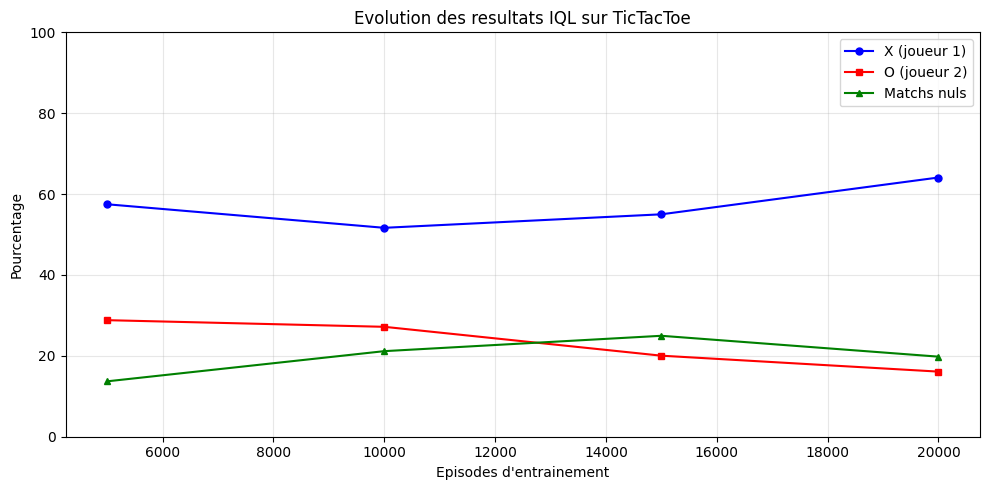

In [7]:
# Visualisation de l'evolution des resultats
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history['episodes'], history['p1_wins'], 'b-o', label='X (joueur 1)', markersize=5)
ax.plot(history['episodes'], history['p2_wins'], 'r-s', label='O (joueur 2)', markersize=5)
ax.plot(history['episodes'], history['draws'], 'g-^', label='Matchs nuls', markersize=5)

ax.set_xlabel("Episodes d'entrainement")
ax.set_ylabel("Pourcentage")
ax.set_title("Evolution des resultats IQL sur TicTacToe")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

Avec TicTacToe, les deux agents devraient converger vers un jeu optimal, ou le joueur qui commence (X) ne peut pas perdre et le second joueur (O) peut au mieux forcer un match nul. La proportion de matchs nuls augmente avec l'entrainement, ce qui est coherent avec la theorie des jeux.

## 6. Evaluation contre un agent aleatoire

Pour verifier que les agents ont appris une politique sensée, mesurons leur taux de victoire contre un joueur aleatoire.

In [8]:
def evaluate_against_random(trained_agent_name, agents, num_games=1000):
    """
    Evalue un agent entraine contre un joueur aleatoire.
    trained_agent_name : 'player_1' ou 'player_2'
    """
    wins, losses, draws = 0, 0, 0
    
    for _ in range(num_games):
        env = tictactoe_v3.env()
        env.reset()
        
        for agent_name in env.agent_iter():
            obs, reward, termination, truncation, info = env.last()
            if termination or truncation:
                break
            
            action_mask = obs['action_mask']
            valid = np.where(action_mask == 1)[0]
            
            if agent_name == trained_agent_name:
                state = encode_observation(obs)
                agent = agents[agent_name]
                # Politique greedy (pas d'exploration)
                q_vals = agent.get_q(state)
                masked_q = np.full(9, -np.inf)
                masked_q[valid] = q_vals[valid]
                action = np.argmax(masked_q)
            else:
                action = np.random.choice(valid)
            
            env.step(action)
        
        r = env.rewards.get(trained_agent_name, 0)
        if r > 0:
            wins += 1
        elif r < 0:
            losses += 1
        else:
            draws += 1
    
    total = wins + losses + draws
    print(f"Agent {trained_agent_name} vs Aleatoire ({num_games} parties) :")
    print(f"  Victoires : {wins/total*100:.1f}%")
    print(f"  Defaites  : {losses/total*100:.1f}%")
    print(f"  Nuls      : {draws/total*100:.1f}%")
    return wins, losses, draws

evaluate_against_random('player_1', agents, num_games=1000)
print()
evaluate_against_random('player_2', agents, num_games=1000)

Agent player_1 vs Aleatoire (1000 parties) :
  Victoires : 91.5%
  Defaites  : 2.8%
  Nuls      : 5.7%



Agent player_2 vs Aleatoire (1000 parties) :
  Victoires : 70.4%
  Defaites  : 9.3%
  Nuls      : 20.3%


(704, 93, 203)

Un agent bien entraine devrait gagner la majorite des parties contre un joueur aleatoire. Le joueur X (qui commence) a un avantage naturel et devrait avoir un taux de victoire plus eleve.

## 7. Visualiser une partie

Observons une partie entre les deux agents entraines pour verifier que le jeu est coherent.

In [9]:
def play_and_display(agents, seed=42):
    """Fait jouer les agents et affiche la grille."""
    env = tictactoe_v3.env()
    env.reset(seed=seed)
    
    board = ['.' for _ in range(9)]
    marks = {'player_1': 'X', 'player_2': 'O'}
    moves = []
    
    for agent_name in env.agent_iter():
        obs, reward, termination, truncation, info = env.last()
        if termination or truncation:
            break
        
        state = encode_observation(obs)
        action_mask = obs['action_mask']
        valid = np.where(action_mask == 1)[0]
        
        agent = agents[agent_name]
        q_vals = agent.get_q(state)
        masked_q = np.full(9, -np.inf)
        masked_q[valid] = q_vals[valid]
        action = np.argmax(masked_q)
        
        board[action] = marks[agent_name]
        moves.append((marks[agent_name], action))
        env.step(action)
    
    print("Partie entre agents entraines :")
    for i, (mark, pos) in enumerate(moves):
        print(f"  Coup {i+1} : {mark} joue en position {pos}")
    
    print("\nGrille finale :")
    for i in range(3):
        print(' '.join(board[i*3:(i+1)*3]))
    
    rewards = env.rewards
    if rewards.get('player_1', 0) > 0:
        print("\nResultat : X gagne")
    elif rewards.get('player_2', 0) > 0:
        print("\nResultat : O gagne")
    else:
        print("\nResultat : Match nul")

play_and_display(agents)

Partie entre agents entraines :
  Coup 1 : X joue en position 0
  Coup 2 : O joue en position 1
  Coup 3 : X joue en position 2
  Coup 4 : O joue en position 3
  Coup 5 : X joue en position 4
  Coup 6 : O joue en position 5
  Coup 7 : X joue en position 6

Grille finale :
X O X
O X O
X . .

Resultat : X gagne


## 8. Exercices

### Exercice 1 : Connect Four

PettingZoo inclut `connect_four_v3`. Adaptez le code IQL pour ce jeu. Observez comment la taille de l'espace d'etat (4^42 vs 3^9) affecte l'apprentissage.

```python
from pettingzoo.classic import connect_four_v3
```

### Exercice 2 : Self-play avec periodically reset

Pour ameliorer la robustesse, entrainez un agent contre des versions passees de lui-meme. Toutes les N episodes, sauvegardez une copie de la table Q et tirez au hasard l'adversaire parmi ces versions.

### Exercice 3 : Ajouter un reward shaping

Au lieu de recompenses uniquement en fin de partie (+1/-1/0), ajoutez des recompenses intermediaires pour :
- Poser un pion au centre de la grille (meilleure strategie d'ouverture)
- Creer une ligne de 2 pions
- Bloquer une ligne de 2 de l'adversaire

In [10]:
# Exercice 1 : Espace de travail pour Connect Four
# from pettingzoo.classic import connect_four_v3
# env = connect_four_v3.env()
# ... adapter IQL pour ce jeu ...

In [11]:
# Exercice 2 : Espace de travail pour self-play avec versions passees
# snapshots = []
# for ep in range(num_episodes):
#     if ep % snapshot_freq == 0:
#         snapshots.append(deepcopy(agents['player_1'].q_table))
#     # Choisir adversaire parmi snapshots ...


In [12]:
# Exercice 3 : Espace de travail pour reward shaping
# Definir une fonction compute_shaped_reward(obs, action, base_reward)


## 9. Conclusion

| Concept | Description |
|---------|-------------|
| **Multi-Agent RL** | Plusieurs agents apprennent simultanement dans un environnement partage |
| **PettingZoo** | API AEC pour environnements multi-agent (equivalent Gymnasium) |
| **IQL** | Chaque agent apprend independamment avec son propre Q-Learning |
| **Non-stationnarite** | Defi principal : l'environnement change du point de vue de chaque agent |
| **Equilibre de Nash** | Convergence vers des strategies ou aucun agent n'a interet a devier |

**Ce que nous avons vu dans cette serie** :

| Notebook | Theme |
|----------|-------|
| RL-1 | Introduction PPO + CartPole (stable-baselines3) |
| RL-2 | Wrappers, callbacks, environnements custom |
| RL-3 | HER, goal-conditioned RL (off-policy) |
| RL-4 | MDP, Value/Policy Iteration, Q-Learning tabulaire |
| RL-5 | DQN, REINFORCE (approximation par reseaux de neurones) |
| RL-6 | Multi-Agent RL, IQL, PettingZoo |

**Pour aller plus loin en Multi-Agent RL** :
- [PettingZoo documentation](https://pettingzoo.farama.org/)
- Busoniu et al. (2008) - *A Comprehensive Survey of Multi-Agent Reinforcement Learning*
- Papoudakis et al. (2021) - *Benchmarking Multi-Agent Deep Reinforcement Learning Algorithms*
- Algorithms avances : QMIX, MAPPO, MADDPG